# Temporal Analysis: The Weekly Panel


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import text
import database as db

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
with db.get_connection() as conn:
    tf = pd.read_sql(text('SELECT * FROM temporal_features ORDER BY week'), conn)

print(f"Total weeks: {len(tf)}")
tf.head()

Total weeks: 86


,week,article_count,average_sentiment,negative_sentiment_ratio,positive_sentiment_ratio,article_count_change,sentiment_change,topic_growth_rate,keyword_growth_rate,entity_growth_rate,...,disaster_recovery_topic_frequency,fuel_keyword_frequency,shortage_keyword_frequency,protest_keyword_frequency,crisis_keyword_frequency,person_entity_frequency,organization_entity_frequency,location_entity_frequency,event_entity_frequency,money_entity_frequency
0,2023-W39,68,-0.154666,0.279412,0.073529,NaN,NaN,NaN,NaN,NaN,...,10,2,0,1,1,57,75,46,7,0
1,2023-W40,184,-0.180878,0.315217,0.043478,1.705880,-0.026213,2.500000,0.500000,1.778380,...,18,2,2,2,0,129,229,136,15,5
2,2023-W41,159,-0.161267,0.295597,0.050314,-0.135870,0.019612,-0.228571,-0.333333,-0.097276,...,29,1,1,1,1,117,178,156,12,1
3,2023-W42,151,-0.173370,0.304636,0.039735,-0.050314,-0.012103,0.055556,-0.250000,0.017241,...,16,1,0,1,1,128,207,121,13,3
4,2023-W43,169,-0.144615,0.254438,0.041420,0.119205,0.028755,0.403509,1.000000,-0.004237,...,29,1,1,3,1,133,197,127,7,6


## 1. Article Volume with Moving Averages

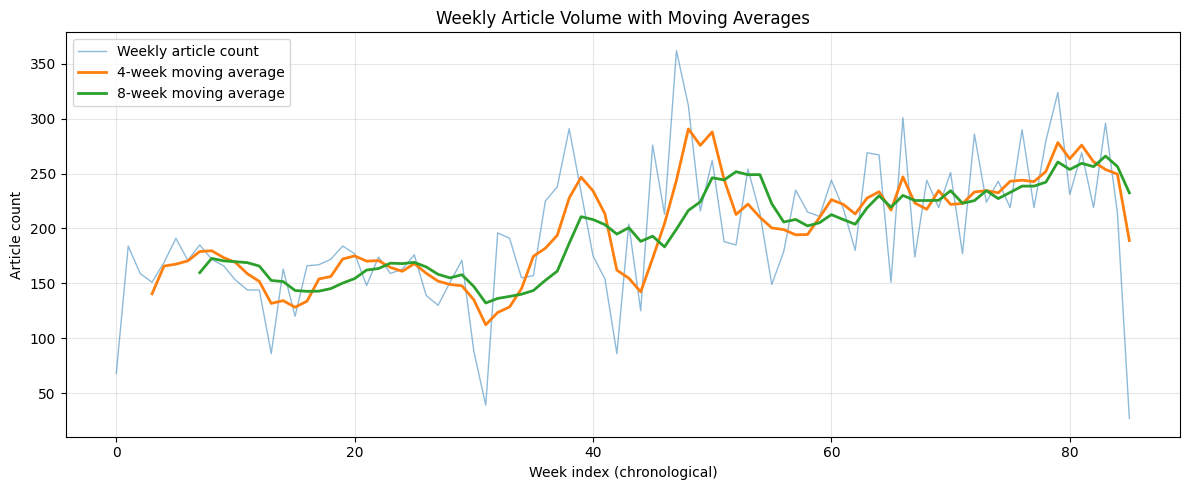

In [3]:
fig, ax = plt.subplots()
x = range(len(tf))
ax.plot(x, tf['article_count'], label='Weekly article count', alpha=0.5, linewidth=1)
ax.plot(x, tf['ma_4week'], label='4-week moving average', linewidth=2)
ax.plot(x, tf['ma_8week'], label='8-week moving average', linewidth=2)
ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Article count')
ax.set_title('Weekly Article Volume with Moving Averages')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Tracked Topics + Crisis Markers (Full Timeline)

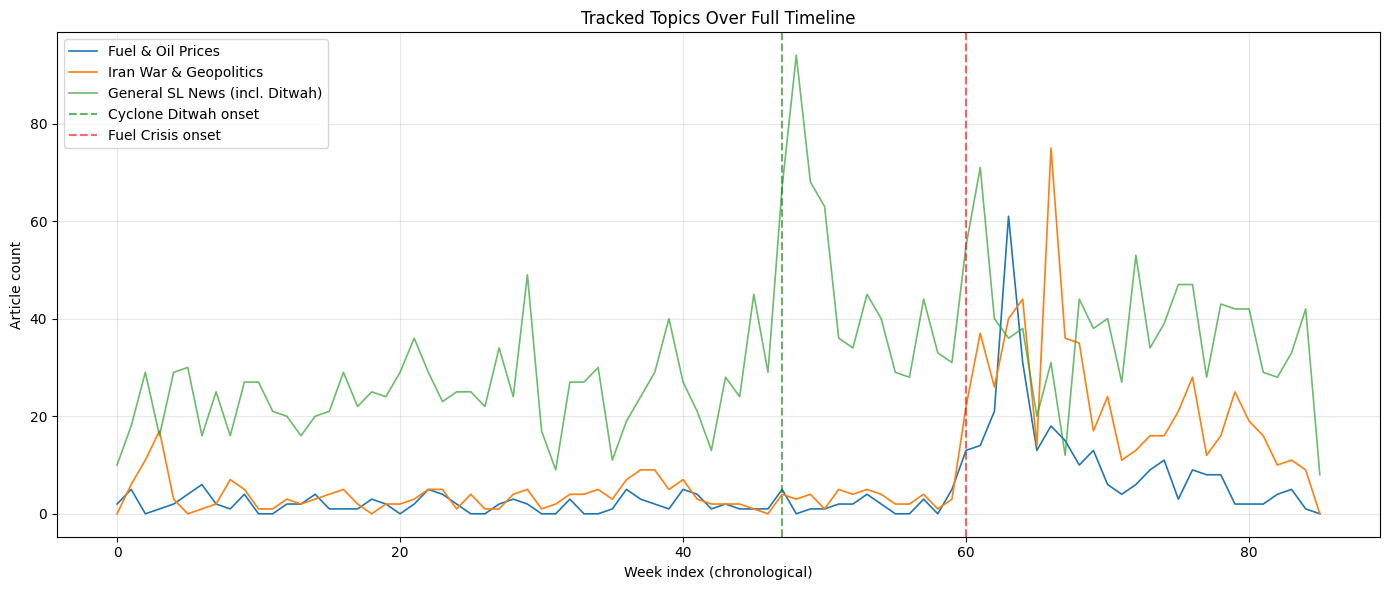

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(tf))
ax.plot(x, tf['fuel_topic_frequency'], label='Fuel & Oil Prices', linewidth=1.2)
ax.plot(x, tf['iran_war_topic_frequency'], label='Iran War & Geopolitics', linewidth=1.2)
ax.plot(x, tf['disaster_recovery_topic_frequency'], label='General SL News (incl. Ditwah)', linewidth=1.2, alpha=0.7)

# Mark crisis weeks
ditwah_idx = tf.index[tf['week'] == '2025-W48'].tolist()
fuel_idx = tf.index[tf['week'] == '2026-W09'].tolist()
if ditwah_idx:
    ax.axvline(ditwah_idx[0], color='green', linestyle='--', alpha=0.6, label='Cyclone Ditwah onset')
if fuel_idx:
    ax.axvline(fuel_idx[0], color='red', linestyle='--', alpha=0.6, label='Fuel Crisis onset')

ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Article count')
ax.set_title('Tracked Topics Over Full Timeline')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Anomaly Score Over Time — The Key Result

Rolling z-score (8-week trailing baseline, current week excluded). Threshold line at z=2 marks
the conventional "anomalous" cutoff.

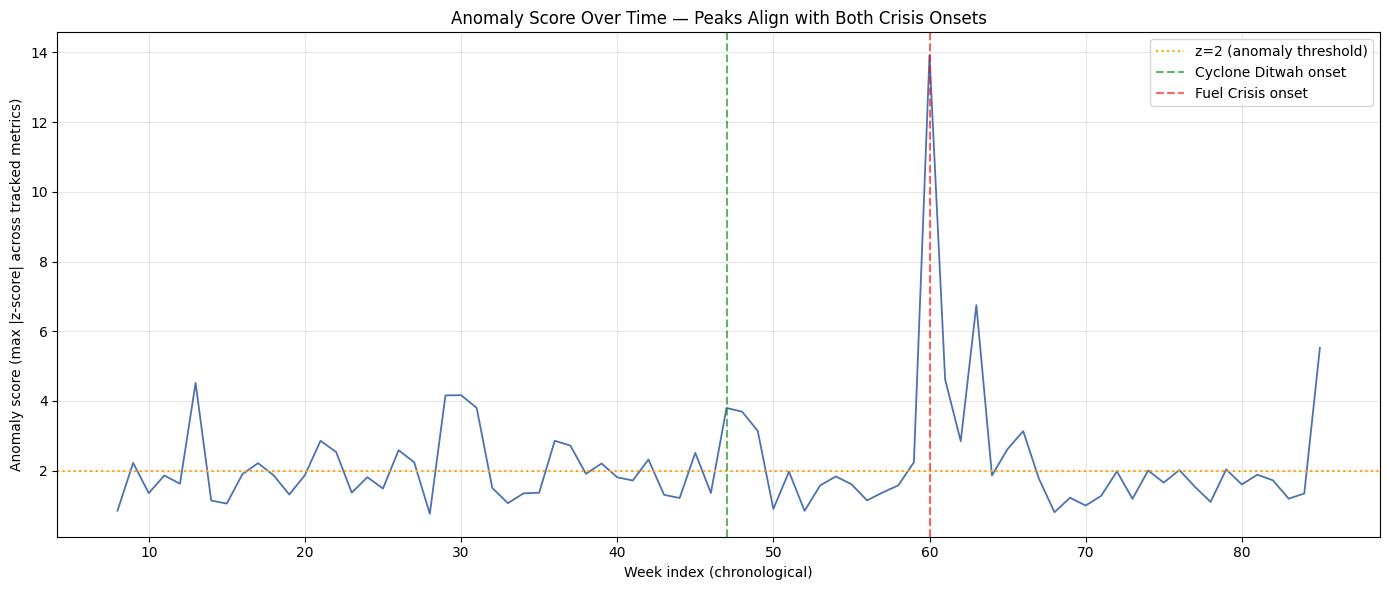

Top 10 highest anomaly weeks:
        week  anomaly_score  fuel_topic_frequency  iran_war_topic_frequency
60  2026-W09       13.91750                    13                        22
63  2026-W12        6.75000                    61                        40
85  2026-W34        5.52137                     0                         0
61  2026-W10        4.62089                    14                        37
13  2023-W52        4.51547                     2                         2
30  2024-W17        4.16641                     0                         1
29  2024-W16        4.15838                     2                         5
31  2025-W30        3.80017                     0                         2
47  2025-W48        3.79827                     5                         4
48  2025-W49        3.69247                     0                         3


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(tf))
ax.plot(x, tf['anomaly_score'], color='#4C72B0', linewidth=1.3)
ax.axhline(2.0, color='orange', linestyle=':', label='z=2 (anomaly threshold)')

if ditwah_idx:
    ax.axvline(ditwah_idx[0], color='green', linestyle='--', alpha=0.6, label='Cyclone Ditwah onset')
if fuel_idx:
    ax.axvline(fuel_idx[0], color='red', linestyle='--', alpha=0.6, label='Fuel Crisis onset')

ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Anomaly score (max |z-score| across tracked metrics)')
ax.set_title('Anomaly Score Over Time — Peaks Align with Both Crisis Onsets')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 highest anomaly weeks:')
print(tf.nlargest(10, 'anomaly_score')[['week', 'anomaly_score', 'fuel_topic_frequency', 'iran_war_topic_frequency']])

## 4. Pre-Crisis Window Labels

Visual confirmation of `label_pre_crisis`: green = pre-crisis (30-day window), gray = normal,
red = excluded (active crisis period).

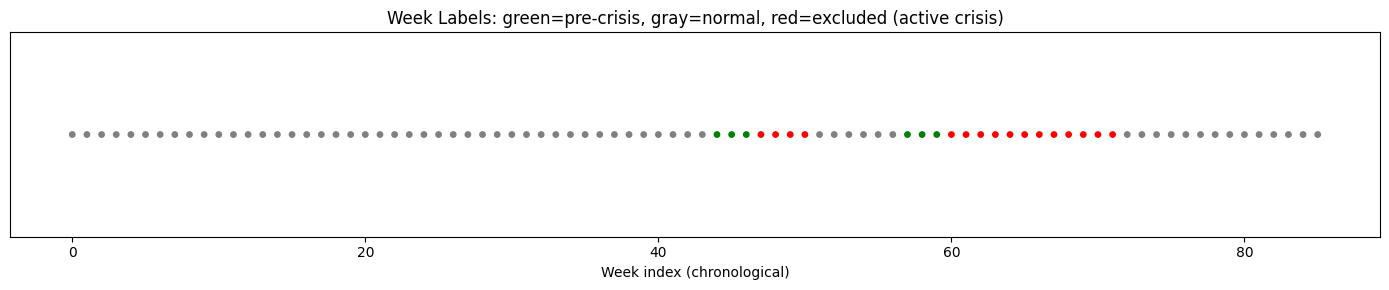

label_pre_crisis
0.0    64
NaN    16
1.0     6
Name: count, dtype: int64


In [6]:
label_colors = tf['label_pre_crisis'].map({1: 'green', 0: 'gray'}).fillna('red')

fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(range(len(tf)), [1]*len(tf), c=label_colors, s=15)
ax.set_yticks([])
ax.set_xlabel('Week index (chronological)')
ax.set_title('Week Labels: green=pre-crisis, gray=normal, red=excluded (active crisis)')
plt.tight_layout()
plt.show()

print(tf['label_pre_crisis'].value_counts(dropna=False))